In [355]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report


#### Load Data

In [299]:
df = pd.read_csv('data/f1_laps_final.csv')

In [300]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint', 'LapTime',
       'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

In [301]:
features_to_keep = ['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber', 'Position',
                    'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL',
                    'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp', 'Humidity',
                    'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'LapsTilPit']

In [302]:
df = df[features_to_keep]

In [303]:
df.dtypes

Driver            object
Team              object
Year               int64
Race              object
Stint            float64
LapTime           object
LapNumber        float64
Position         float64
Sector1Time       object
Sector2Time       object
Sector3Time       object
SpeedI1          float64
SpeedI2          float64
SpeedFL          float64
Compound          object
TyreLife         float64
FreshTyre          int64
TrackStatus        int64
AirTemp          float64
Humidity         float64
Pressure         float64
Rainfall           int64
TrackTemp        float64
WindDirection    float64
WindSpeed        float64
LapsTilPit       float64
dtype: object

In [304]:
df.shape

(77230, 26)

In [305]:
df.head(2)

,Driver,Team,Year,Race,Stint,LapTime,LapNumber,Position,Sector1Time,Sector2Time,...,FreshTyre,TrackStatus,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,LapsTilPit
0,VER,Red Bull Racing,2022,Bahrain Grand Prix,1.0,0 days 00:01:40.236000,1.0,2.0,NaN,0 days 00:00:42.325000,...,0,1,23.9,25.0,1010.2,0,29.1,20.0,0.5,14.0
1,SAI,Ferrari,2022,Bahrain Grand Prix,1.0,0 days 00:01:41.006000,1.0,3.0,NaN,0 days 00:00:42.889000,...,0,1,23.9,25.0,1010.2,0,29.1,20.0,0.5,14.0


## Feature Engineering

#### Convert time columns to seconds

In [306]:
# Convert time columns
for col in ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']:
    df[col] = pd.to_timedelta(df[col]).dt.total_seconds()

#### Fill missing values with rolling median

In [307]:
df.isnull().sum()

Driver               0
Team                 0
Year                 0
Race                 0
Stint                0
LapTime              0
LapNumber            0
Position             0
Sector1Time       1379
Sector2Time         24
Sector3Time         37
SpeedI1          12012
SpeedI2             46
SpeedFL           2532
Compound             0
TyreLife             0
FreshTyre            0
TrackStatus          0
AirTemp              0
Humidity             0
Pressure             0
Rainfall             0
TrackTemp            0
WindDirection        0
WindSpeed            0
LapsTilPit           0
dtype: int64

In [308]:
cols_with_nulls = ['Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL']

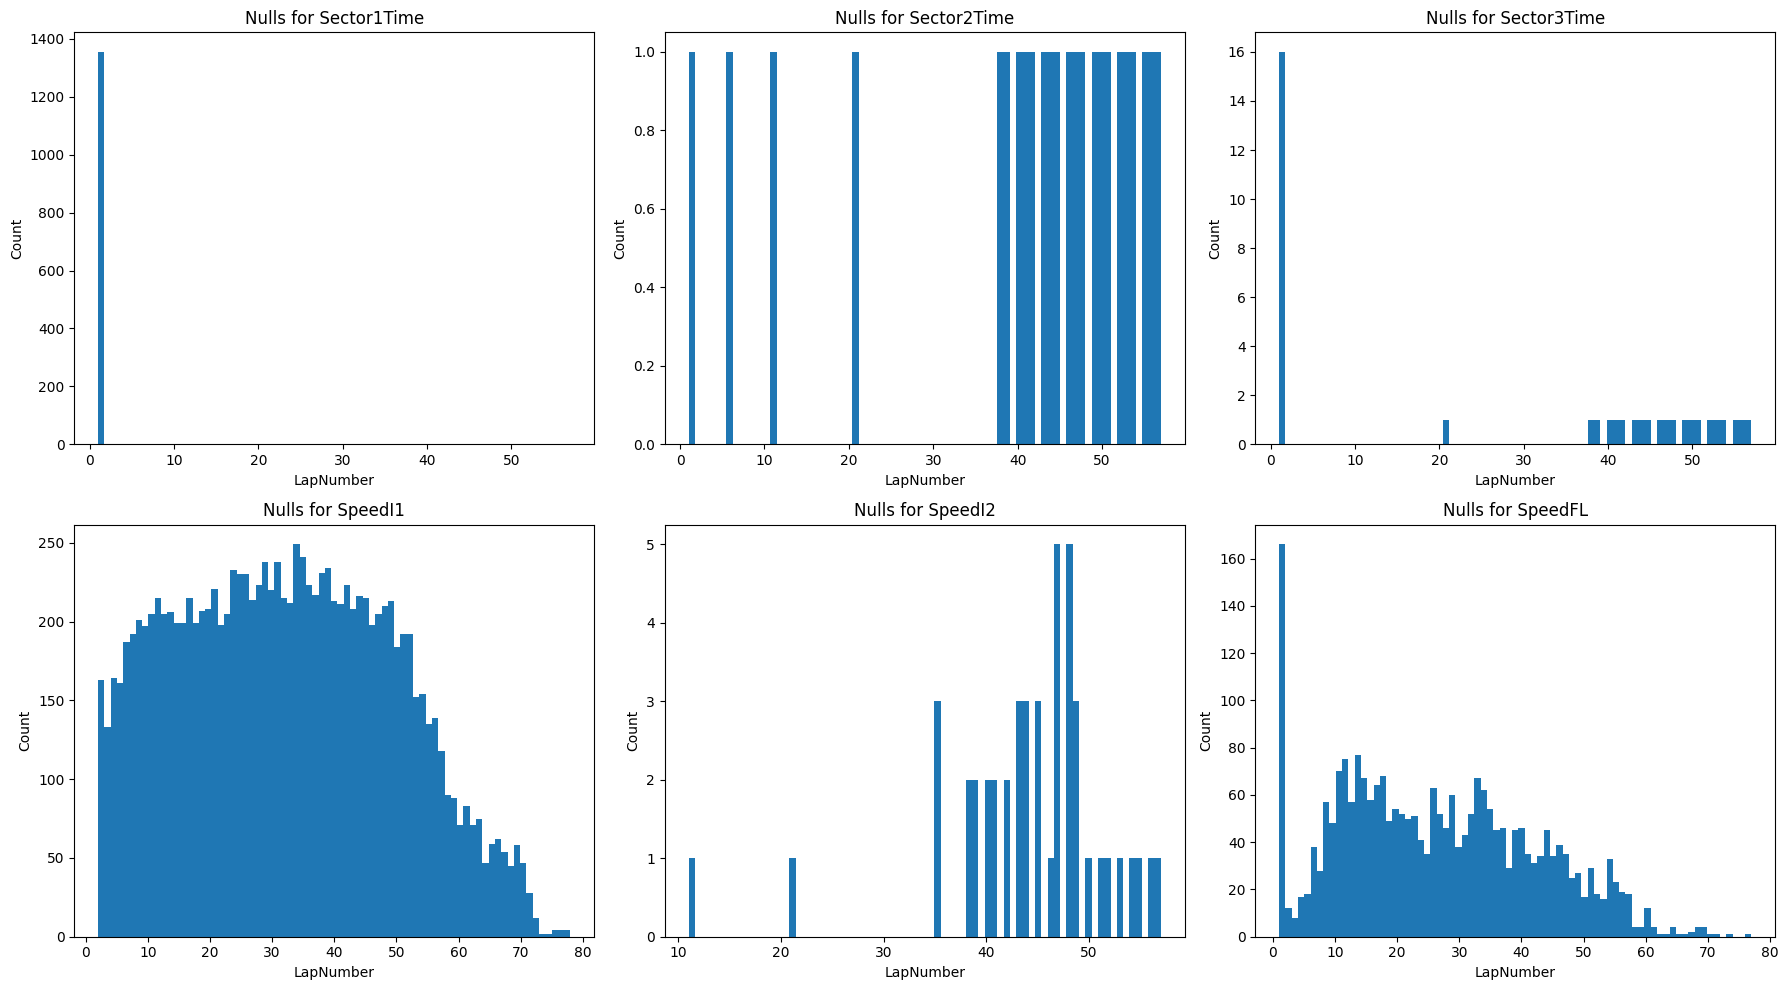

In [309]:
# Plot nulls
plt.figure(figsize=(18, 10))
for i, col in enumerate(cols_with_nulls, 1):
    plt.subplot(2, 3, i)
    # Lap numbers where this column is null
    lap_nulls = df.loc[df[col].isnull(), 'LapNumber']
    plt.hist(lap_nulls, bins=75)
    plt.title(f"Nulls for {col}")
    plt.xlabel("LapNumber")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [310]:
# Impute rolling median for each group, so each value is filled using only previous values
def rolling_group_median_impute(df, cols, group_cols, order_col):
    df = df.sort_values(group_cols + [order_col]).copy()
    for col in cols:
        # Compute rolling median of previous values within each group
        df[col + '_imputed'] = (
            df.groupby(group_cols)[col]
            .transform(lambda s: s.expanding().median().shift(1))
        )
        # Where imputed is still NaN, try forward fill as backup (still causal)
        df[col + '_imputed'] = (
            df[col + '_imputed'].combine_first(
                df.groupby(group_cols)[col].ffill()
            )
        )
        # Drop original and rename
        df[col] = df[col + '_imputed']
        df.drop(columns=[col + '_imputed'], inplace=True)
    return df

In [311]:
df_imputed = df.copy()

In [312]:
# Columns to group by before calculating median
group_cols = ['Year', 'Race', 'Driver', 'Stint']

df_imputed = rolling_group_median_impute(df_imputed, cols_with_nulls, group_cols, 'LapNumber')

In [313]:
df[cols_with_nulls].isnull().sum()

Sector1Time     1379
Sector2Time       24
Sector3Time       37
SpeedI1        12012
SpeedI2           46
SpeedFL         2532
dtype: int64

In [314]:
df_imputed[cols_with_nulls].isnull().sum()

Sector1Time    1356
Sector2Time       1
Sector3Time      16
SpeedI1           4
SpeedI2           1
SpeedFL         179
dtype: int64

In [315]:
# Sum nulls for each row across these columns
df['null_count'] = df[cols_with_nulls].isnull().sum(axis=1)

# Group and count total nulls
null_group_counts = (
    df.groupby(['Year', 'Race', 'Driver', 'Stint'])['null_count']
      .sum()
      .reset_index()
      .sort_values('null_count', ascending=False)
)

null_group_counts

,Year,Race,Driver,Stint,null_count
3514,2025,Bahrain Grand Prix,RUS,3.0,120
1527,2023,Canadian Grand Prix,TSU,3.0,23
3266,2024,Saudi Arabian Grand Prix,ALO,2.0,20
2752,2024,Dutch Grand Prix,HUL,2.0,20
1567,2023,Dutch Grand Prix,PER,3.0,19
...,...,...,...,...,...
673,2022,Italian Grand Prix,LEC,4.0,0
3629,2025,Emilia Romagna Grand Prix,VER,3.0,0
676,2022,Italian Grand Prix,MAG,3.0,0
678,2022,Italian Grand Prix,MSC,2.0,0


In [316]:
# Define group
year, race, driver, stint = 2025, 'Bahrain Grand Prix', 'RUS', 3.0

mask = (
    (df['Year'] == year) &
    (df['Race'] == race) &
    (df['Driver'] == driver) &
    (df['Stint'] == stint)
)

In [317]:
df.loc[mask, ['LapNumber'] + cols_with_nulls]

,LapNumber,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL
72073,34.0,44.861,61.138,34.521,188.0,157.0,196.0
72093,35.0,42.720,60.997,41.812,184.0,167.0,285.0
72113,36.0,30.752,41.505,23.261,236.0,252.0,284.0
72152,38.0,NaN,NaN,NaN,NaN,NaN,NaN
72172,39.0,NaN,NaN,NaN,NaN,NaN,NaN
72192,40.0,NaN,NaN,NaN,NaN,NaN,NaN
72212,41.0,NaN,NaN,NaN,NaN,NaN,NaN
72232,42.0,NaN,NaN,NaN,NaN,NaN,NaN
72252,43.0,NaN,NaN,NaN,NaN,NaN,NaN
72272,44.0,NaN,NaN,NaN,NaN,NaN,NaN


In [318]:
df_imputed.loc[mask, ['LapNumber'] + cols_with_nulls]

,LapNumber,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL
72073,34.0,44.8610,61.1380,34.5210,188.0,157.0,196.0
72093,35.0,44.8610,61.1380,34.5210,188.0,157.0,196.0
72113,36.0,43.7905,61.0675,38.1665,186.0,162.0,240.5
72152,38.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72172,39.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72192,40.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72212,41.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72232,42.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72252,43.0,42.7200,60.9970,34.5210,188.0,167.0,284.0
72272,44.0,42.7200,60.9970,34.5210,188.0,167.0,284.0


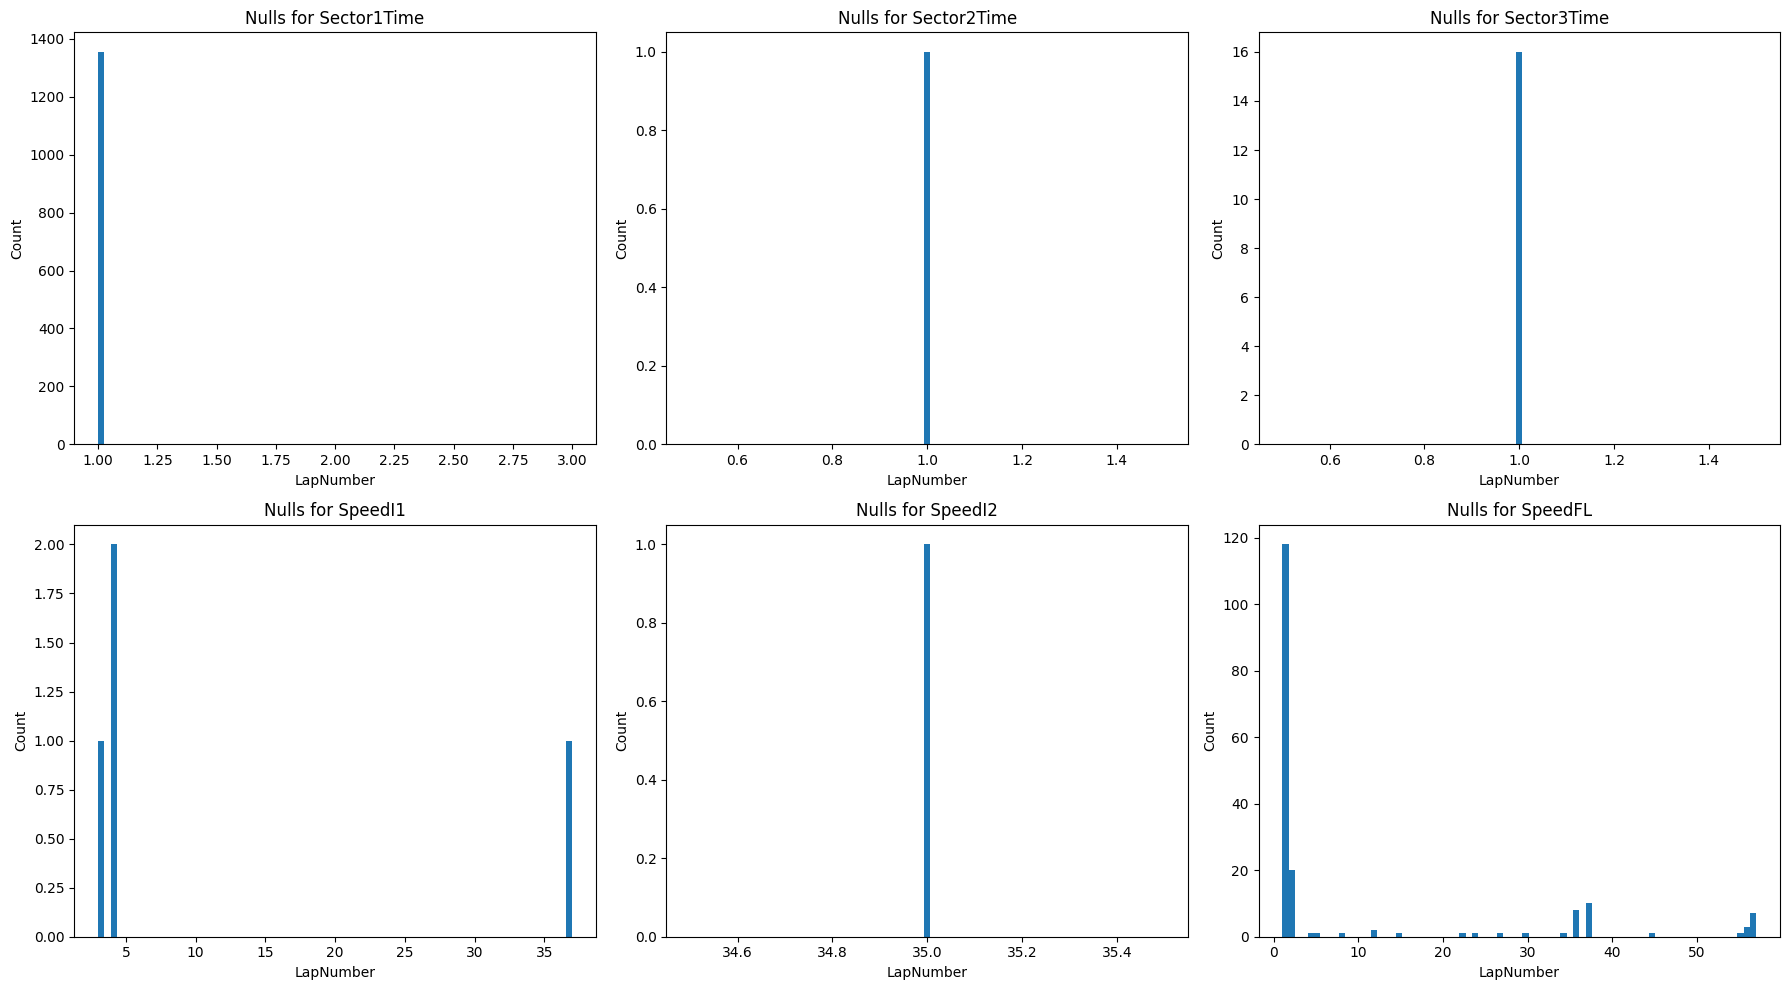

In [319]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(cols_with_nulls, 1):
    plt.subplot(2, 3, i)
    # Lap numbers where this column is null
    lap_nulls = df_imputed.loc[df_imputed[col].isnull(), 'LapNumber']
    plt.hist(lap_nulls, bins=75)
    plt.title(f"Nulls for {col}")
    plt.xlabel("LapNumber")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [320]:
lap_nulls.value_counts()

LapNumber
1.0     118
2.0      20
37.0     10
36.0      8
57.0      7
56.0      3
12.0      2
4.0       1
30.0      1
45.0      1
8.0       1
34.0      1
24.0      1
55.0      1
22.0      1
5.0       1
15.0      1
27.0      1
Name: count, dtype: int64

#### Drop remaining nulls

In [321]:
df_clean = df_imputed.dropna(subset=cols_with_nulls).copy()

In [322]:
df_clean.isnull().sum()

Driver           0
Team             0
Year             0
Race             0
Stint            0
LapTime          0
LapNumber        0
Position         0
Sector1Time      0
Sector2Time      0
Sector3Time      0
SpeedI1          0
SpeedI2          0
SpeedFL          0
Compound         0
TyreLife         0
FreshTyre        0
TrackStatus      0
AirTemp          0
Humidity         0
Pressure         0
Rainfall         0
TrackTemp        0
WindDirection    0
WindSpeed        0
LapsTilPit       0
dtype: int64

In [323]:
df_encoded = df_clean.copy()

#### Convert bools to ints

In [336]:
# Turn bool values into int
bool_cols = ['FreshTyre', 'Rainfall']
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

#### Encode categorical columns

In [325]:
# Label encode
categorical_cols = ['Driver', 'Team', 'Race', 'Compound', 'TrackStatus']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

# Save mapping for use at inference
n_classes = [df_encoded[col].nunique() for col in categorical_cols]

In [326]:
df_encoded[categorical_cols]

,Driver,Team,Race,Compound,TrackStatus
20540,0,12,0,1,0
20559,0,12,0,1,0
20579,0,12,0,1,0
20599,0,12,0,1,0
20618,0,12,0,1,0
...,...,...,...,...,...
77148,28,11,22,0,0
77165,28,11,22,0,0
77182,28,11,22,0,0
77200,28,11,22,0,0


#### Standardize numeric columns

In [327]:
# Save for creating sliding windows later
df_encoded['StintRaw'] = df_encoded['Stint']
df_encoded['LapNumberRaw'] = df_encoded['LapNumber']


In [328]:
# Standardize numeric columns
numeric_cols = ['Stint', 'LapTime', 'LapNumber', 'Position', 'TyreLife',
                'Sector1Time', 'Sector2Time', 'Sector3Time',
                'SpeedI1', 'SpeedI2', 'SpeedFL',
                'AirTemp', 'Humidity', 'Pressure',
                'TrackTemp', 'WindDirection', 'WindSpeed']

# Split by year first to avoid data leakage
train_idx = df_encoded['Year'] <= 2023
val_idx   = df_encoded['Year'] == 2024
test_idx  = df_encoded['Year'] == 2025

# Fit scaler only on train
scaler = StandardScaler()
df_encoded.loc[train_idx, numeric_cols] = scaler.fit_transform(df_encoded.loc[train_idx, numeric_cols])
df_encoded.loc[val_idx, numeric_cols]   = scaler.transform(df_encoded.loc[val_idx, numeric_cols])
df_encoded.loc[test_idx, numeric_cols]  = scaler.transform(df_encoded.loc[test_idx, numeric_cols])

In [329]:
df_encoded[numeric_cols].describe()

,Stint,LapTime,LapNumber,Position,TyreLife,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,AirTemp,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed
count,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000,75809.000000
mean,-0.065372,-0.012382,0.005147,0.007482,0.026328,0.018435,-0.024331,-0.003055,-0.014306,0.039511,0.036518,-0.042430,0.003046,0.096738,0.043621,-0.000423,-0.020422
std,0.972687,0.965325,1.008434,1.004719,1.043243,0.982700,0.956449,1.049429,0.960418,0.995110,0.959760,1.007545,0.900948,0.935463,1.043693,1.009309,0.956877
min,-1.230756,-1.762111,-1.651016,-1.626226,-1.345164,-1.541209,-2.307232,-1.685807,-4.206258,-4.280799,-6.483152,-2.418563,-2.589978,-3.550779,-2.527390,-1.820985,-1.562692
25%,-1.230756,-0.727093,-0.857371,-0.883532,-0.750900,-0.559106,-0.685075,-0.689377,-0.831370,-0.744617,-0.560418,-0.807817,-0.637407,0.126897,-0.658234,-0.725036,-0.656802
50%,-0.202214,-0.119261,-0.007036,0.044835,-0.156636,-0.026098,-0.247212,-0.264541,0.357270,0.226100,0.226311,0.018751,0.032046,0.468396,0.044268,-0.014700,-0.245034
75%,0.826328,0.530834,0.786609,0.787529,0.536672,0.373564,0.699267,0.513203,0.686268,0.757683,0.627098,0.781736,0.645712,0.559462,0.872216,0.858000,0.413795
max,4.940495,4.252638,2.657345,1.901570,6.281225,7.920917,4.991346,8.394065,1.970424,2.179089,2.408371,2.689199,2.096194,0.692559,2.728828,1.822028,5.519721


In [330]:
# Create binary label
df_encoded['PitNext3Laps'] = (df_encoded['LapsTilPit'] <= 3).astype(int)

In [331]:
df_encoded['PitNext3Laps'].value_counts()

PitNext3Laps
0    65137
1    10672
Name: count, dtype: int64

#### Build sliding window sequences

In [332]:
df_encoded.shape

(75809, 29)

In [333]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1',
       'SpeedI2', 'SpeedFL', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'LapsTilPit', 'StintRaw',
       'LapNumberRaw', 'PitNext3Laps'],
      dtype='object')

In [337]:
feature_cols = categorical_cols + numeric_cols + bool_cols
window_size = 3

def make_sequences(df, feature_cols, label_col, group_cols, window_size):
    X_seqs, y_seqs, years = [], [], []
    for key, group in df.groupby(group_cols):
        group = group.sort_values('LapNumberRaw')
        feats = group[feature_cols].values
        labels = group[label_col].values
        lap_nums = group['LapNumberRaw'].values
        yrs = group['Year'].values
        for i in range(window_size, len(group)):
            # Check if this window's lap numbers are sequential
            window_laps = lap_nums[i-window_size:i+1]  # window_size + 1 numbers (includes label lap)
            # Should increase by exactly 1 each time (difference between consecutive laps == 1)
            if np.all(np.diff(window_laps) == 1):
                X_seqs.append(feats[i-window_size:i])
                y_seqs.append(labels[i])
                years.append(yrs[i])
    return np.array(X_seqs), np.array(y_seqs), np.array(years)

X, y, years = make_sequences(
    df_encoded, feature_cols, 'PitNext3Laps',
    group_cols=['Year', 'Race', 'Driver', 'StintRaw'],
    window_size=window_size
)

In [338]:
print(X.shape)
print(y.shape)

(64514, 3, 24)
(64514,)


In [339]:
X[0][0]

array([ 0.        , 12.        ,  0.        ,  1.        ,  0.        ,
       -1.23075629,  0.13822538, -1.65101633,  1.15887631, -1.24611969,
       -1.31157408,  0.66913408,  1.33435429,  0.78178413,  1.1968164 ,
       -1.58465037,  0.88770609,  0.58992409,  0.56296436, -0.13135758,
        1.33494032,  1.31968545,  1.        ,  0.        ])

## LSTM Model

#### Train, val, test split

In [340]:
X_train, X_val, X_test = X[years <= 2023], X[years == 2024], X[years == 2025]
y_train, y_val, y_test = y[years <= 2023], y[years == 2024], y[years == 2025]

In [341]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(37243, 3, 24)
(37243,)
(20405, 3, 24)
(20405,)
(6866, 3, 24)
(6866,)


#### Prepare inputs

In [427]:
# Find indices for categorical and numeric features in the windowed X
cat_idx = [feature_cols.index(col) for col in categorical_cols]
num_idx = [feature_cols.index(col) for col in numeric_cols + bool_cols]

def split_features(X, cat_idx, num_idx):
    # Split along last dimension
    X_cat = [X[..., idx].astype(int) for idx in cat_idx]      # List of arrays for each cat col
    X_num = X[..., num_idx].astype(float)                     # All numerics together
    return X_cat, X_num

X_train_cat, X_train_num = split_features(X_train, cat_idx, num_idx)
X_val_cat, X_val_num     = split_features(X_val, cat_idx, num_idx)
X_test_cat, X_test_num   = split_features(X_test, cat_idx, num_idx)

#### Build LSTM Model

In [454]:
window_size = X_train_num.shape[1]
num_numeric = X_train_num.shape[2]
embedding_dim = 8  # or tune per categorical variable

# Inputs
num_input = tf.keras.layers.Input(shape=(window_size, num_numeric), name='num_input')
cat_inputs = [tf.keras.layers.Input(shape=(window_size,), name=col) for col in categorical_cols]

# Embeddings
cat_embeds = [
    tf.keras.layers.Embedding(input_dim=n, output_dim=embedding_dim, mask_zero=False, name=f'{col}_emb')(cat_input)
    for cat_input, n, col in zip(cat_inputs, n_classes, categorical_cols)
]

# Concatenate numerics and all embeddings along the feature axis
x = tf.keras.layers.Concatenate(axis=-1)([num_input] + cat_embeds)

# LSTM
x = tf.keras.layers.LSTM(32, return_sequences=False)(x)
x = tf.keras.layers.Dropout(0.2)(x)
out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(inputs=[num_input] + cat_inputs, outputs=out)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()], )

# Print summary
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Driver (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Team (InputLayer)   │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Race (InputLayer)   │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Compound            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TrackStatus         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 3, 19)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Driver_emb          │ (None, 3, 8)      │        248 │ Driver[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Team_emb            │ (None, 3, 8)      │        104 │ Team[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Race_emb            │ (None, 3, 8)      │        200 │ Race[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Compound_emb        │ (None, 3, 8)      │         24 │ Compound[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TrackStatus_emb     │ (None, 3, 8)      │        224 │ TrackStatus[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 3, 59)     │          0 │ num_input[0][0],  │
│ (Concatenate)       │                   │            │ Driver_emb[0][0], │
│                     │                   │            │ Team_emb[0][0],   │
│                     │                   │            │ Race_emb[0][0],   │
│                     │                   │            │ Compound_emb[0][… │
│                     │                   │            │ TrackStatus_emb[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32)        │     11,776 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,609 (49.25 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Training

In [455]:
# Format the training data as a list of arrays
train_inputs = [X_train_num] + X_train_cat
val_inputs = [X_val_num] + X_val_cat

model.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=10, batch_size=128
)

Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7829 - auc_3: 0.6130 - loss: 0.4830 - val_accuracy: 0.8413 - val_auc_3: 0.7512 - val_loss: 0.3790
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8414 - auc_3: 0.7957 - loss: 0.3683 - val_accuracy: 0.8356 - val_auc_3: 0.7635 - val_loss: 0.3764
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8539 - auc_3: 0.8312 - loss: 0.3393 - val_accuracy: 0.8292 - val_auc_3: 0.7775 - val_loss: 0.3754
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8587 - auc_3: 0.8465 - loss: 0.3274 - val_accuracy: 0.8096 - val_auc_3: 0.7711 - val_loss: 0.4015
Epoch 5/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8653 - auc_3: 0.8637 - loss: 0.3122 - val_accuracy: 0.8167 - val_auc_3: 0.7728 - val_loss: 0.3990
Epoch 6/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8712 - auc_3: 0.8753 - loss: 0.3004 - val_accuracy: 0.8009 - val_auc_3: 0.7747 - val_loss: 0.4218
Epoch 7/10
291/2

#### Visualize results

In [456]:
# Predict class probabilities
y_train_pred = model.predict(train_inputs)
y_val_pred = model.predict(val_inputs)
y_test_pred = model.predict([X_test_num] + X_test_cat)

# Bin probablities
y_train_pred_bin = (y_train_pred > 0.5).astype(int).flatten()
y_val_pred_bin   = (y_val_pred > 0.5).astype(int).flatten()
y_test_pred_bin  = (y_test_pred > 0.5).astype(int).flatten()

1164/1164 ━━━━━━━━━━━━━━━━━━━━ 1s 431us/step
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step


In [399]:
def print_results(y_true, y_pred, split_name):
    # Print confusion matrix
    print(f"--- {split_name} Results ---\n")
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    # Print classification report
    print(f"Classification Report:")
    print(classification_report(y_true, y_pred))

In [461]:
print_results(y_train, y_train_pred_bin, "Train")

--- Train Results ---

Confusion Matrix:
[[30037  1073]
 [ 2723  3410]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     31110
           1       0.76      0.56      0.64      6133

    accuracy                           0.90     37243
   macro avg       0.84      0.76      0.79     37243
weighted avg       0.89      0.90      0.89     37243



In [462]:
print_results(y_val, y_val_pred_bin, "Validation")

--- Validation Results ---

Confusion Matrix:
[[14632  2646]
 [ 1625  1502]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87     17278
           1       0.36      0.48      0.41      3127

    accuracy                           0.79     20405
   macro avg       0.63      0.66      0.64     20405
weighted avg       0.82      0.79      0.80     20405



In [463]:
print_results(y_test, y_test_pred_bin, "Test")

--- Test Results ---

Confusion Matrix:
[[4450 1314]
 [ 590  512]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      5764
           1       0.28      0.46      0.35      1102

    accuracy                           0.72      6866
   macro avg       0.58      0.62      0.59      6866
weighted avg       0.79      0.72      0.75      6866



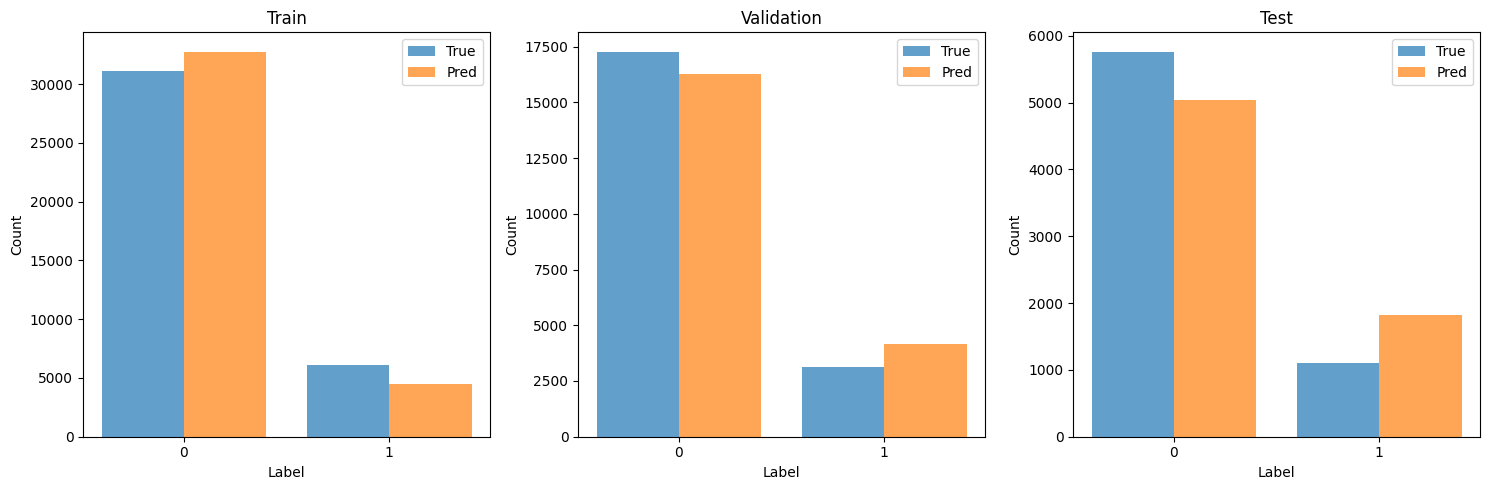

In [464]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [("Train", y_train, y_train_pred_bin),
          ("Validation", y_val, y_val_pred_bin),
          ("Test", y_test, y_test_pred_bin)]

for ax, (name, y_true, y_pred) in zip(axes, splits):
    true_counts = np.bincount(y_true.astype(int))
    pred_counts = np.bincount(y_pred.astype(int))
    x = np.arange(2)
    ax.bar(x - 0.2, true_counts, width=0.4, label='True', alpha=0.7)
    ax.bar(x + 0.2, pred_counts, width=0.4, label='Pred', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(['0', '1'])
    ax.set_title(name)
    ax.legend()
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Exploring Model Results

In [465]:
# Get only the last row in each window:
X_val_last = X_val[:, -1, :]  # shape: (num_windows, num_features)
val_results = pd.DataFrame(X_val_last, columns=feature_cols)

# Add predictions and true labels back to validation set
val_results['TrueLabel'] = y_val           # true pit/npit
val_results['PredLabel'] = y_val_pred_bin  # prediction of model trained on public features
val_results['Correct'] = (val_results['TrueLabel'] == val_results['PredLabel'])

In [466]:
# Reverse categorical encoding
for col in categorical_cols:
    val_results[col] = encoders[col].inverse_transform(val_results[col].astype(int))

In [467]:
# Reverse standardization
val_results[numeric_cols] = scaler.inverse_transform(val_results[numeric_cols])

In [468]:
val_results.shape

(20405, 27)

In [469]:
val_results.columns

Index(['Driver', 'Team', 'Race', 'Compound', 'TrackStatus', 'Stint', 'LapTime',
       'LapNumber', 'Position', 'TyreLife', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'FreshTyre',
       'Rainfall', 'TrueLabel', 'PredLabel', 'Correct'],
      dtype='object')

In [470]:
val_results.iloc[500]

Driver                            NOR
Team                          McLaren
Race             Abu Dhabi Grand Prix
Compound                       MEDIUM
TrackStatus                         1
Stint                             1.0
LapTime                        89.133
LapNumber                        21.0
Position                          1.0
TyreLife                         21.0
Sector1Time                    18.079
Sector2Time                   38.4255
Sector3Time                   32.6435
SpeedI1                         284.0
SpeedI2                         295.0
SpeedFL                         212.5
AirTemp                          26.7
Humidity                         52.0
Pressure                       1017.5
TrackTemp                        31.3
WindDirection                   226.0
WindSpeed                         1.3
FreshTyre                         1.0
Rainfall                          0.0
TrueLabel                           0
PredLabel                           1
Correct     

In [471]:
# False Positives: Predicted 1 (pit soon), actually 0 (not pitting soon)
false_positives = val_results[(val_results['PredLabel'] == 1) & (val_results['TrueLabel'] == 0)]

# False Negatives: Predicted 0, actually 1
false_negatives = val_results[(val_results['PredLabel'] == 0) & (val_results['TrueLabel'] == 1)]

In [472]:
# Mean TyreLife for FP/FN
print("False Positives: Mean TyreLife", false_positives['TyreLife'].mean())
print("False Negatives: Mean TyreLife", false_negatives['TyreLife'].mean())

False Positives: Mean TyreLife 23.03174603174603
False Negatives: Mean TyreLife 18.044307692307694


In [473]:
print('Stint Precision')
print(val_results.groupby('Stint')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Stint').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Stint').size())

Stint Precision
Stint
1.0    0.699965
2.0    0.841972
3.0    0.809110
4.0    0.750000
5.0    0.713450
Name: Correct, dtype: float64

False Positives
Stint
1.0    1096
2.0     903
3.0     470
4.0     142
5.0      35
dtype: int64

False Negatives
Stint
1.0    622
2.0    594
3.0    343
4.0     52
5.0     14
dtype: int64


In [474]:
print('Compound Precision')
print(val_results.groupby('Compound')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Compound').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Compound').size())

Compound Precision
Compound
HARD      0.834178
MEDIUM    0.729331
SOFT      0.720800
Name: Correct, dtype: float64

False Positives
Compound
HARD      1221
MEDIUM    1239
SOFT       186
dtype: int64

False Negatives
Compound
HARD      776
MEDIUM    686
SOFT      163
dtype: int64


In [475]:
print('Rainfall Precision')
print(val_results.groupby('Rainfall')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Rainfall').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Rainfall').size())

Rainfall Precision
Rainfall
0.0    0.792465
1.0    0.555556
Name: Correct, dtype: float64

False Positives
Rainfall
0.0    2584
1.0      62
dtype: int64

False Negatives
Rainfall
0.0    1619
1.0       6
dtype: int64


In [476]:
print('TrackStatus Precision')
print(val_results.groupby('TrackStatus')['Correct'].agg(['count', 'mean']))

TrackStatus Precision
             count      mean
TrackStatus                 
1            19647  0.790655
12             305  0.721311
124             25  0.920000
126             15  0.466667
1264            12  1.000000
1267             7  1.000000
14               2  0.500000
16              13  0.769231
167             21  0.238095
21              27  0.703704
24               3  1.000000
26              15  0.200000
2671             1  1.000000
4              165  0.975758
41             101  0.970297
6               14  0.214286
64               5  0.600000
671             17  0.823529
71              10  1.000000
